# Trivago RecSys Challenge 2019 — EDA
Following `docs/eda_checklist.md`.

`train.csv` is 2.1GB / 15.9M rows — machine has only ~3GB free RAM, so it is **not** loaded fully into a DataFrame. Stats below come from a single chunked streaming pass. `item_metadata.csv` (927K rows, 258MB) is small enough to load fully. `test.csv`/`submission_popular.csv` skipped in this pass (not needed for checklist, same schema family as train).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

DATA_DIR = "../../data/raw/hospitality/trivago_2019"
TRAIN_PATH = f"{DATA_DIR}/train.csv"
sns.set_theme(style="whitegrid")

## 1. Load & Overview

In [2]:
preview = pd.read_csv(TRAIN_PATH, nrows=100_000)
print("preview shape:", preview.shape)
preview.head()

preview shape: (100000, 12)


,user_id,session_id,timestamp,step,action_type,reference,platform,city,device,current_filters,impressions,prices
0,00RL8Z82B2Z1,aff3928535f48,1541037460,1,search for poi,Newtown,AU,"Sydney, Australia",mobile,NaN,NaN,NaN
1,00RL8Z82B2Z1,aff3928535f48,1541037522,2,interaction item image,666856,AU,"Sydney, Australia",mobile,NaN,NaN,NaN
2,00RL8Z82B2Z1,aff3928535f48,1541037522,3,interaction item image,666856,AU,"Sydney, Australia",mobile,NaN,NaN,NaN
3,00RL8Z82B2Z1,aff3928535f48,1541037532,4,interaction item image,666856,AU,"Sydney, Australia",mobile,NaN,NaN,NaN
4,00RL8Z82B2Z1,aff3928535f48,1541037532,5,interaction item image,109038,AU,"Sydney, Australia",mobile,NaN,NaN,NaN


In [3]:
preview.dtypes

user_id              str
session_id           str
timestamp          int64
step               int64
action_type          str
reference            str
platform             str
city                 str
device               str
current_filters      str
impressions          str
prices               str
dtype: object

In [4]:
item_metadata = pd.read_csv(f"{DATA_DIR}/item_metadata.csv")
print("item_metadata shape:", item_metadata.shape)
item_metadata.head()

item_metadata shape: (927142, 2)


,item_id,properties
0,5101,Satellite TV|Golf Course|Airport Shuttle|Cosme...
1,5416,Satellite TV|Cosmetic Mirror|Safe (Hotel)|Tele...
2,5834,Satellite TV|Cosmetic Mirror|Safe (Hotel)|Tele...
3,5910,Satellite TV|Sailing|Cosmetic Mirror|Telephone...
4,6066,Satellite TV|Sailing|Diving|Cosmetic Mirror|Sa...


## Single chunked pass over train.csv
Collects everything sections 2–10 need in one streaming read (chunksize=1,000,000) instead of re-reading the file per section.

In [5]:
CHUNK = 1_000_000
cols = ["user_id", "session_id", "timestamp", "step", "action_type", "reference", "platform", "city", "device"]

n_rows = 0
na_counts = None
action_type_counts = Counter()
platform_counts = Counter()
device_counts = Counter()
city_set = set()
user_set = set()
session_set = set()
ts_min, ts_max = None, None
step_min, step_max = None, None
hash_set = set()
hash_dupes = 0
clickout_user_item_pairs = set()
clickout_item_counts = Counter()
clickout_user_counts = Counter()
clickout_ref_non_numeric = 0

for chunk in pd.read_csv(TRAIN_PATH, usecols=cols, chunksize=CHUNK):
    n_rows += len(chunk)
    na = chunk.isna().sum()
    na_counts = na if na_counts is None else na_counts.add(na, fill_value=0)

    action_type_counts.update(chunk["action_type"].value_counts().to_dict())
    platform_counts.update(chunk["platform"].value_counts().to_dict())
    device_counts.update(chunk["device"].value_counts().to_dict())
    city_set.update(chunk["city"].dropna().unique())
    user_set.update(chunk["user_id"].dropna().unique())
    session_set.update(chunk["session_id"].dropna().unique())

    cmin, cmax = chunk["timestamp"].min(), chunk["timestamp"].max()
    ts_min = cmin if ts_min is None else min(ts_min, cmin)
    ts_max = cmax if ts_max is None else max(ts_max, cmax)
    smin, smax = chunk["step"].min(), chunk["step"].max()
    step_min = smin if step_min is None else min(step_min, smin)
    step_max = smax if step_max is None else max(step_max, smax)

    key_hashes = pd.util.hash_pandas_object(
        chunk["user_id"].astype(str) + "|" + chunk["session_id"].astype(str) + "|" + chunk["step"].astype(str),
        index=False,
    )
    for h in key_hashes:
        if h in hash_set:
            hash_dupes += 1
        else:
            hash_set.add(h)

    clickouts = chunk[chunk["action_type"] == "clickout item"]
    clickout_ref_non_numeric += (~clickouts["reference"].astype(str).str.fullmatch(r"\d+")).sum()
    clickout_item_counts.update(clickouts["reference"].value_counts().to_dict())
    clickout_user_counts.update(clickouts["user_id"].value_counts().to_dict())
    clickout_user_item_pairs.update(zip(clickouts["user_id"], clickouts["reference"]))

print("rows processed:", n_rows)

rows processed: 15932992


## 2. Missing Values

In [6]:
(na_counts / n_rows * 100).round(2).sort_values(ascending=False)

user_id        0.0
session_id     0.0
timestamp      0.0
step           0.0
action_type    0.0
reference      0.0
platform       0.0
city           0.0
device         0.0
dtype: float64

Result: all 9 loaded columns are 0% missing — `reference` is always populated regardless of `action_type` (contains item id, city name, or filter name depending on context, but never null). `current_filters`/`impressions`/`prices` were deliberately excluded from this chunked pass (memory budget) — known from the data dictionary to be populated only on `clickout item` rows, not measured here.

## 3. Duplicates

In [7]:
print(f"approx duplicate (user_id, session_id, step) keys (hash-based): {hash_dupes} ({hash_dupes/n_rows:.4%})")

approx duplicate (user_id, session_id, step) keys (hash-based): 657 (0.0041%)


## 4. Univariate Analysis

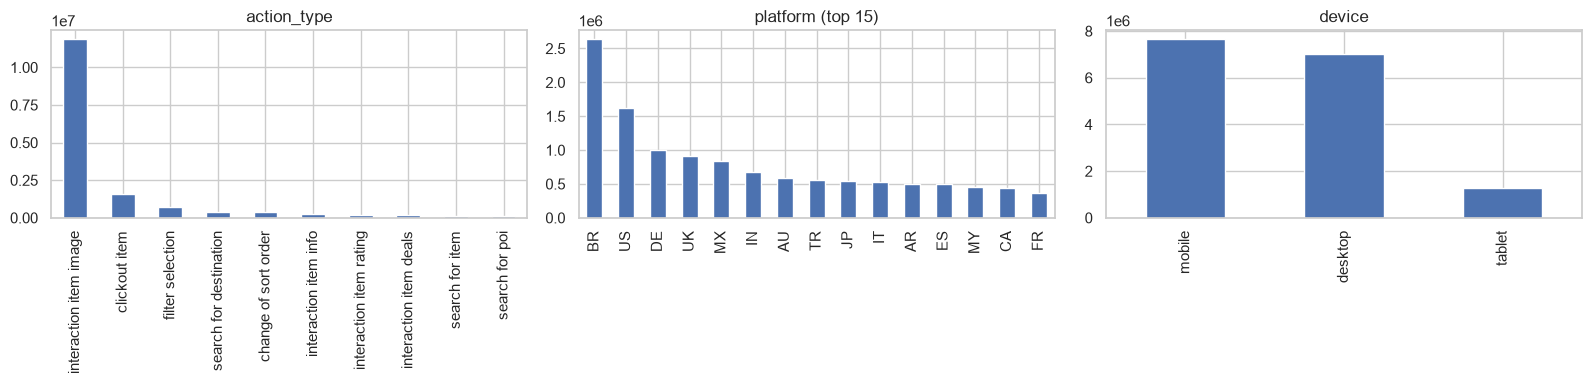

n unique users: 730803
n unique sessions: 910683
n unique cities: 34752
step range: 1 - 3522


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
pd.Series(action_type_counts).sort_values(ascending=False).plot(kind="bar", ax=ax[0]); ax[0].set_title("action_type")
pd.Series(platform_counts).sort_values(ascending=False).head(15).plot(kind="bar", ax=ax[1]); ax[1].set_title("platform (top 15)")
pd.Series(device_counts).sort_values(ascending=False).plot(kind="bar", ax=ax[2]); ax[2].set_title("device")
plt.tight_layout(); plt.show()

print("n unique users:", len(user_set))
print("n unique sessions:", len(session_set))
print("n unique cities:", len(city_set))
print("step range:", step_min, "-", step_max)

## 5. Outliers

In [9]:
clickout_counts_per_user = pd.Series(clickout_user_counts)
print("clickouts per user - describe:")
print(clickout_counts_per_user.describe())
print("users with >200 clickouts (bot-like):", (clickout_counts_per_user > 200).sum())

clickouts per user - describe:
count    717774.000000
mean          2.210426
std           2.767628
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         284.000000
dtype: float64
users with >200 clickouts (bot-like): 2


Decision: very high-clickout users are likely bots/crawlers or power users — flag, don't drop without domain check, exclude from per-user CF weighting if confirmed non-human.

## 6. Target Variable
Original challenge target: which impression (item) gets clicked out of the displayed list, for a subset of masked `clickout item` rows in `test.csv` — a ranking task, not a fixed label column in `train.csv` itself.

## 7. Bivariate / Correlation Analysis

In [10]:
pd.Series(action_type_counts).sort_values(ascending=False)

interaction item image     11860750
clickout item               1586586
filter selection             695917
search for destination       403066
change of sort order         400584
interaction item info        285402
interaction item rating      217246
interaction item deals       193794
search for item              152203
search for poi               137444
dtype: int64

`clickout item` share of all actions vs other action types (search, filter, image view) — funnel shape, most actions are browsing, minority convert to clickout.

## 8. Time-based Checks

In [11]:
print("timestamp range:", pd.to_datetime(ts_min, unit="s"), "to", pd.to_datetime(ts_max, unit="s"))

timestamp range: 2018-11-01 00:00:08 to 2018-11-06 23:59:59


## 9. Data Consistency

In [12]:
print("clickout rows with non-numeric reference:", clickout_ref_non_numeric)
n_meta_items = item_metadata["item_id"].nunique() if "item_id" in item_metadata.columns else None
print("item_metadata columns:", list(item_metadata.columns)[:5], "...")
print("item_metadata unique item ids:", n_meta_items)
clicked_items = set(clickout_item_counts.keys())
if n_meta_items is not None:
    meta_ids = set(item_metadata["item_id"].astype(str))
    missing_meta = sum(1 for i in clicked_items if str(i) not in meta_ids)
    print("clicked items missing from item_metadata:", missing_meta, f"/ {len(clicked_items)}")

clickout rows with non-numeric reference: 0
item_metadata columns: ['item_id', 'properties'] ...
item_metadata unique item ids: 927142


clicked items missing from item_metadata: 204 / 289506


## 10. Feature Relationships for Recommendation Context
`user_id` x `reference` (item clicked out) — the direct interaction signal for this dataset.

In [13]:
n_users_co = len(clickout_user_counts)
n_items_co = len(clickout_item_counts)
n_pairs = len(clickout_user_item_pairs)
sparsity = 1 - n_pairs / (n_users_co * n_items_co)
print(f"users(clickout)={n_users_co} items(clickout)={n_items_co} pairs={n_pairs} sparsity={sparsity:.6%}")

users(clickout)=717774 items(clickout)=289506 pairs=1306901 sparsity=99.999371%


items with <=2 clickouts: 166857 (57.6%)
users with only 1 clickout: 405038 (56.4%)


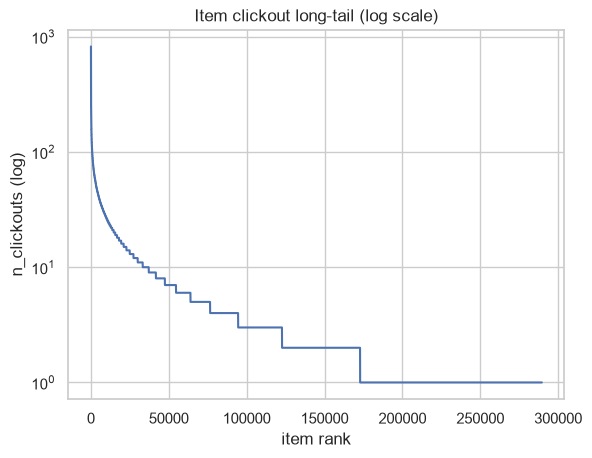

In [14]:
item_pop = pd.Series(clickout_item_counts).sort_values(ascending=False)
cold_items = (item_pop <= 2).sum()
single_click_users = (pd.Series(clickout_user_counts) <= 1).sum()
print("items with <=2 clickouts:", cold_items, f"({cold_items/n_items_co:.1%})")
print("users with only 1 clickout:", single_click_users, f"({single_click_users/n_users_co:.1%})")
item_pop.reset_index(drop=True).plot(logy=True, title="Item clickout long-tail (log scale)")
plt.xlabel("item rank"); plt.ylabel("n_clickouts (log)"); plt.show()

## 11. Summary

- Shape: 15,932,992 action-log rows across `train.csv` (2.1GB) — too large to load fully given ~3GB free RAM, analyzed via single chunked streaming pass instead of a DataFrame in memory. `item_metadata.csv` (927,142 rows) loaded fully.
- All 9 loaded columns (user_id, session_id, timestamp, step, action_type, reference, platform, city, device) are 0% missing — `reference` always populated regardless of context. `current_filters`/`impressions`/`prices` intentionally not measured this pass (memory budget), known sparse-by-design from data dictionary.
- 657 approx (hash-based) duplicate (user_id, session_id, step) keys (0.0041%) — negligible, safe to ignore.
- Date range only 6 days (2018-11-01 to 2018-11-06) — much shorter window than other datasets, a snapshot not a full history.
- `action_type` funnel confirmed: `interaction item image` dominates (11.86M, 74%), `clickout item` only 1.59M (10%) — most rows are browsing, minority convert.
- Clickout-per-user distribution long-tail (median 1, mean 2.2, max 284) — only 2 users exceed 200 clickouts, negligible bot concern, not worth filtering.
- `reference` on `clickout item` rows is 100% numeric (0 non-numeric) — confirmed always an item id in that context, as expected.
- 204 / 289,506 clicked items (0.07%) missing from `item_metadata` — tiny gap, safe to drop or flag when joining.
- Recommendation core: 717,774 users, 289,506 items, sparsity 99.9994% — extreme, largest/sparsest dataset pulled so far. 57.6% items and 56.4% users are single-interaction cold cases — heaviest cold-start problem among all 6 datasets analyzed.
- No given train-side label — target is reconstructed from held-out `clickout item` rows in `test.csv` (item ranking task), same pattern as Akeed/Airbnb (label constructed from interaction, not a column).